In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    brier_score_loss, roc_curve, precision_recall_curve, confusion_matrix
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
import joblib
import json
import os

print("All imports successful")


All imports successful


In [31]:
df = pd.read_csv('finance_marketing_01.csv')
print(f'Dataset shape: {df.shape}')
print(f'Churn rate:      {df["churned"].mean():.3f}  ({df["churned"].sum():,} churned)')
print(f'Cross-sell rate: {df["cross_sell_accepted"].mean():.3f}  ({df["cross_sell_accepted"].sum():,} accepted)')
df.head(3)

Dataset shape: (60000, 44)
Churn rate:      0.163  (9,762 churned)
Cross-sell rate: 0.245  (14,702 accepted)


,customer_id,age,gender,marital_status,education_level,occupation,city_tier,region,annual_income,account_type,...,click_through_rate,preferred_campaign_channel,last_campaign_type,days_since_last_campaign,campaign_offer_category,clv_score,clv_segment,risk_segment,churned,cross_sell_accepted
0,CUST000001,56,Male,Married,Master,Student,Tier 3,North,18269,Basic,...,0.1,Push Notification,Retention,43,No Active Offer,290,Low,Very High Risk,0,0
1,CUST000002,69,Female,Married,Bachelor,Salaried,Tier 3,East,92215,Premium,...,0.0,SMS,Upgrade,268,Savings Plan,359,Medium,High Risk,0,0
2,CUST000003,46,Male,Married,High School,Retired,Tier 3,Central,25823,Basic,...,0.1,SMS,Cross-sell,341,No Active Offer,381,Medium,High Risk,1,0


In [32]:
info = pd.DataFrame({
    'dtype':    df.dtypes,
    'missing':  df.isnull().sum(),
    'missing%': (df.isnull().mean() * 100).round(2)
})
print("Columns with missing values")
print(info[info['missing'] > 0].to_string())

Columns with missing values
             dtype  missing  missing%
nps_score  float64     6057      10.1


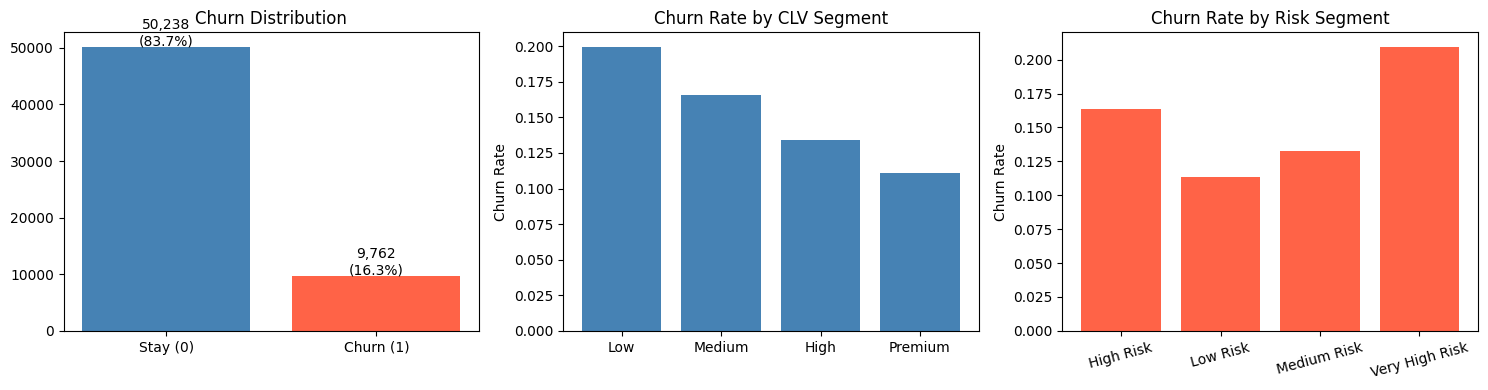

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

churn_counts = df['churned'].value_counts()
axes[0].bar(['Stay (0)', 'Churn (1)'], churn_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Churn Distribution')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

clv_churn = df.groupby('clv_segment')['churned'].mean().reindex(['Low','Medium','High','Premium'])
axes[1].bar(clv_churn.index, clv_churn.values, color='steelblue')
axes[1].set_title('Churn Rate by CLV Segment')
axes[1].set_ylabel('Churn Rate')

risk_churn = df.groupby('risk_segment')['churned'].mean()
axes[2].bar(risk_churn.index, risk_churn.values, color='tomato')
axes[2].set_title('Churn Rate by Risk Segment')
axes[2].set_ylabel('Churn Rate')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

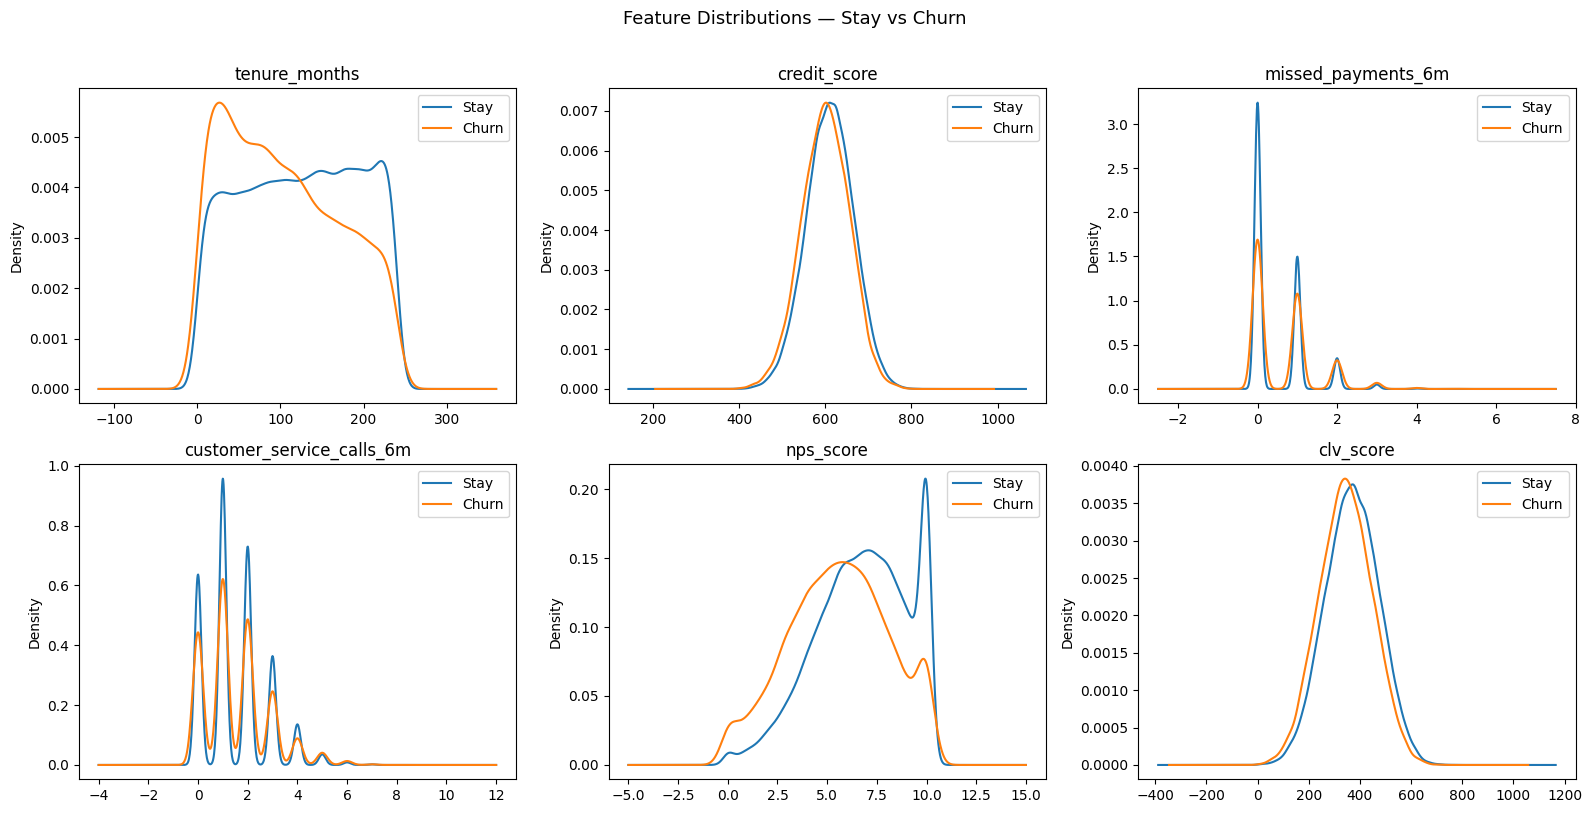

In [34]:
features_to_plot = [
    'tenure_months', 'credit_score', 'missed_payments_6m',
    'customer_service_calls_6m', 'nps_score', 'clv_score'
]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), features_to_plot):
    df.groupby('churned')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)
    ax.legend(['Stay', 'Churn'])
plt.suptitle('Feature Distributions — Stay vs Churn', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

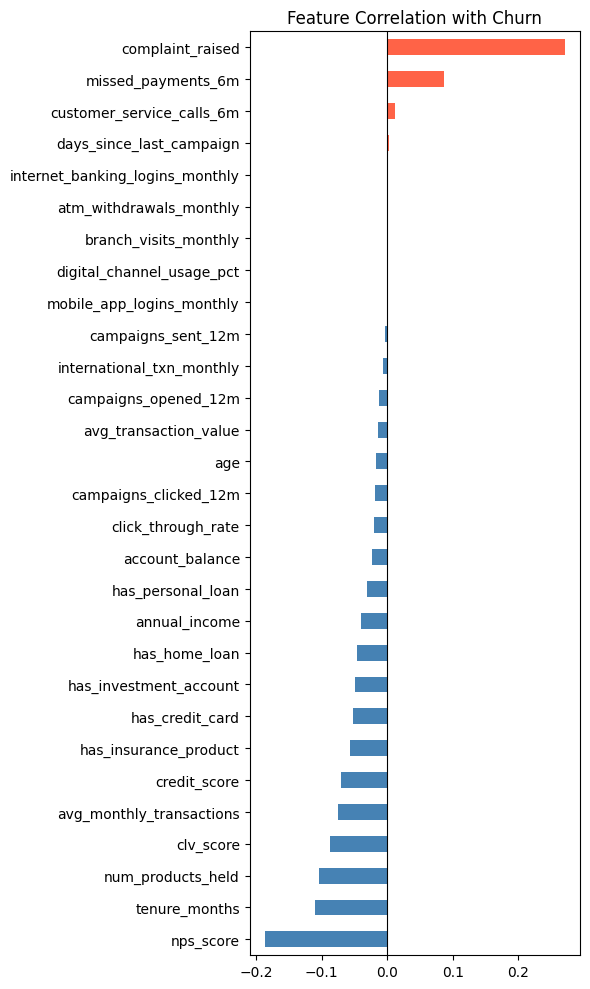

In [35]:
numeric_df = df.select_dtypes('number').drop(columns=['cross_sell_accepted'])
corr_with_churn = numeric_df.corr()['churned'].drop('churned').sort_values()
fig, ax = plt.subplots(figsize=(6, 10))
corr_with_churn.plot(kind='barh', ax=ax, color=['tomato' if v > 0 else 'steelblue' for v in corr_with_churn])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Churn')
plt.tight_layout()
plt.show()

In [36]:
DROP_COLS = [
    'customer_id',
    'clv_segment',      
    'risk_segment',       
    'internet_banking_logins_monthly',   
    'mobile_app_logins_monthly',         
]

df_model = df.drop(columns=DROP_COLS + ['cross_sell_accepted']).copy()
print(f'Model dataframe shape: {df_model.shape}')
print(f'Remaining columns ({len(df_model.columns)}):')
print(df_model.columns.tolist())

Model dataframe shape: (60000, 38)
Remaining columns (38):
['age', 'gender', 'marital_status', 'education_level', 'occupation', 'city_tier', 'region', 'annual_income', 'account_type', 'tenure_months', 'credit_score', 'account_balance', 'num_products_held', 'has_credit_card', 'has_personal_loan', 'has_home_loan', 'has_investment_account', 'has_insurance_product', 'avg_monthly_transactions', 'avg_transaction_value', 'digital_channel_usage_pct', 'atm_withdrawals_monthly', 'international_txn_monthly', 'missed_payments_6m', 'branch_visits_monthly', 'customer_service_calls_6m', 'complaint_raised', 'nps_score', 'campaigns_sent_12m', 'campaigns_opened_12m', 'campaigns_clicked_12m', 'click_through_rate', 'preferred_campaign_channel', 'last_campaign_type', 'days_since_last_campaign', 'campaign_offer_category', 'clv_score', 'churned']


In [37]:
def engineer_features(df_in):
    df_out = df_in.copy()

    # df_out['campaign_open_rate'] = df_out['campaigns_opened_12m'] / (df_out['campaigns_sent_12m'] + 1)
    # df_out['balance_income_ratio'] = df_out['account_balance'] / (df_out['annual_income'] + 1)
    # df_out['savings_efficiency']   = df_out['account_balance'] / (df_out['avg_monthly_transactions'] + 1)
    df_out['risk_indicator']       = df_out['missed_payments_6m'] + df_out['complaint_raised']
    # df_out['monthly_txn_volume']   = df_out['avg_monthly_transactions'] * df_out['avg_transaction_value']
    nps_median = df_out['nps_score'].median()
    nps_filled = df_out['nps_score'].fillna(nps_median)
    df_out['complaint_nps_interaction'] = (10 - nps_filled) * (df_out['complaint_raised'] + 1)
    # df_out['products_per_tenure']  = df_out['num_products_held'] / (df_out['tenure_months'] / 12 + 1)

    return df_out

df_model = engineer_features(df_model)
print(f'Shape after feature engineering: {df_model.shape}')

Shape after feature engineering: (60000, 40)


In [38]:
ordinal_cols_map = {
    'education_level': ['High School', 'Bachelor', 'Master', 'PhD'],
    'city_tier':       ['Tier 3', 'Tier 2', 'Tier 1'],
}

nominal_cols = [
    'gender', 'marital_status', 'occupation', 'region',
    'account_type', 'preferred_campaign_channel',
    'last_campaign_type', 'campaign_offer_category'
]

numeric_cols = (
    df_model.drop(columns=['churned'])
    .select_dtypes('number')
    .columns.tolist()
)

print(f'Numeric features:  {len(numeric_cols)}')
print(f'Ordinal features:  {len(ordinal_cols_map)}')
print(f'Nominal features:  {len(nominal_cols)}')
print(f'Total input features: {len(numeric_cols) + len(ordinal_cols_map) + len(nominal_cols)}')

Numeric features:  29
Ordinal features:  2
Nominal features:  8
Total input features: 39


In [39]:
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')), 
    ('scale',  RobustScaler())
])

ordinal_pipeline = Pipeline([
    ('encode', OrdinalEncoder(
        categories=[ordinal_cols_map[c] for c in ordinal_cols_map],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

nominal_pipeline = Pipeline([
    ('encode', OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,              numeric_cols),
    ('ord', ordinal_pipeline,              list(ordinal_cols_map.keys())),
    ('nom', nominal_pipeline,              nominal_cols),
], remainder='drop')

print('Preprocessor built successfully.')

Preprocessor built successfully.


In [40]:
X = df_model.drop(columns=['churned'])
y = df_model['churned']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f'Train:     {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test:      {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTrain churn rate:     {y_train.mean():.3f}')
print(f'Validation churn rate: {y_val.mean():.3f}')
print(f'Test churn rate:      {y_test.mean():.3f}')

Train:     42,000 rows (70.0%)
Validation: 9,000 rows (15.0%)
Test:      9,000 rows (15.0%)

Train churn rate:     0.163
Validation churn rate: 0.163
Test churn rate:      0.163


In [41]:
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print(f'Preprocessed train shape: {X_train_prep.shape}')
print(f'Preprocessed validation shape: {X_val_prep.shape}')
print(f'Preprocessed test shape:  {X_test_prep.shape}')

print(f'\nOriginal class distribution in training:')
print(f'  Stay:  {(y_train == 0).sum():,}')
print(f'  Churn: {(y_train == 1).sum():,}')

Preprocessed train shape: (42000, 59)
Preprocessed validation shape: (9000, 59)
Preprocessed test shape:  (9000, 59)

Original class distribution in training:
  Stay:  35,167
  Churn: 6,833


In [42]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    auc    = roc_auc_score(y_te, y_prob)
    pr_auc = average_precision_score(y_te, y_prob)
    brier  = brier_score_loss(y_te, y_prob)

    print("\n")
    print(f"  {name} : ")
    print(classification_report(y_te, y_pred, target_names=['Stay', 'Churn']))
    print(f"  AUC-ROC : {auc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}")
    print(f"  Brier   : {brier:.4f}\n")
    return {'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
            'auc': auc, 'pr_auc': pr_auc, 'brier': brier}

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

baseline_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=0.1, random_state=42,
        class_weight='balanced'  
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10,
        min_samples_leaf=20, n_jobs=-1, random_state=42,
        class_weight='balanced' 
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
        random_state=42, n_jobs=-1,
        scale_pos_weight=scale_pos 
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=63, random_state=42, n_jobs=-1, verbose=-1,
        class_weight='balanced'  
    ),
}

results = {}
for name, model in baseline_models.items():
    results[name] = evaluate_model(
        name, model,
        X_train_prep, y_train,
        X_test_prep, y_test
    )

best_name = max(results, key=lambda n: results[n]['pr_auc'])
print(f"\n")
print(f" Best baseline model by PR-AUC: {best_name}  ({results[best_name]['pr_auc']:.4f})")



  Logistic Regression : 
              precision    recall  f1-score   support

        Stay       0.90      0.72      0.80      7536
       Churn       0.29      0.60      0.39      1464

    accuracy                           0.70      9000
   macro avg       0.60      0.66      0.60      9000
weighted avg       0.80      0.70      0.73      9000

  AUC-ROC : 0.7216
  PR-AUC  : 0.3706
  Brier   : 0.2078



  Random Forest : 
              precision    recall  f1-score   support

        Stay       0.89      0.80      0.85      7536
       Churn       0.33      0.50      0.40      1464

    accuracy                           0.75      9000
   macro avg       0.61      0.65      0.62      9000
weighted avg       0.80      0.75      0.77      9000

  AUC-ROC : 0.7151
  PR-AUC  : 0.3620
  Brier   : 0.1928



  XGBoost : 
              precision    recall  f1-score   support

        Stay       0.90      0.75      0.82      7536
       Churn       0.30      0.55      0.39      1464

   

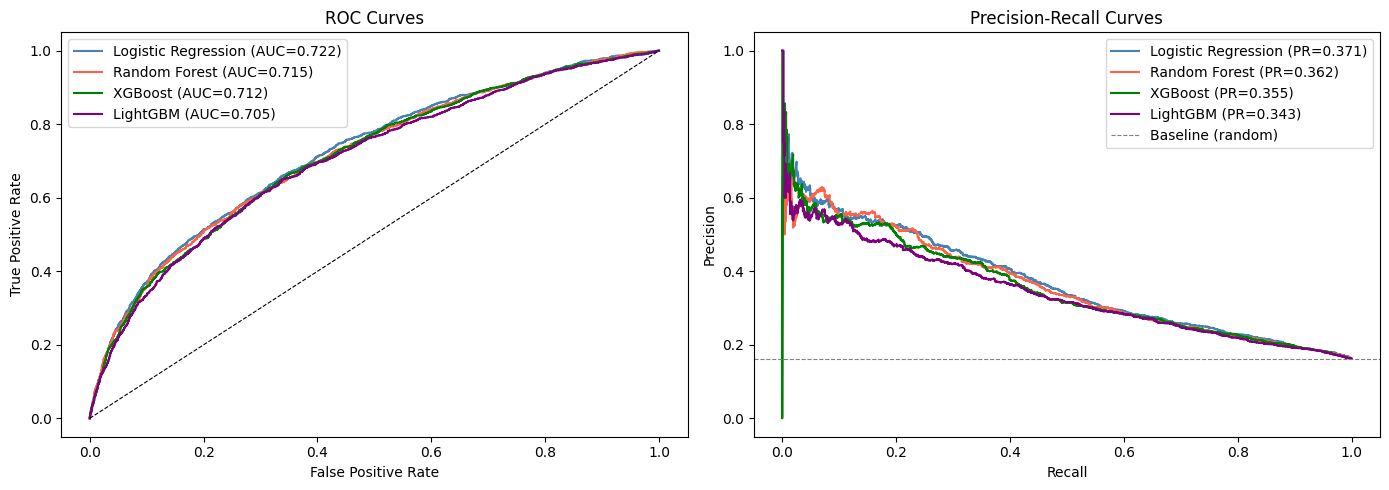

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'tomato', 'green', 'purple']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])

    ax1.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color)
    ax2.plot(rec, prec, label=f"{name} (PR={res['pr_auc']:.3f})", color=color)

ax1.plot([0,1],[0,1],'k--', linewidth=0.8)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves'); ax1.legend()

ax2.axhline(y_test.mean(), color='grey', linestyle='--', linewidth=0.8, label='Baseline (random)')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves'); ax2.legend()

plt.tight_layout()
plt.show()

In [46]:
from sklearn.calibration import CalibratedClassifierCV

lr_param_grid = {
    'C':        [0.001, 0.01, 0.1, 1, 10],
    'penalty':  ['l1', 'l2'],
    'solver':   ['liblinear'],    
    'max_iter': [1000]
}

lr_base = LogisticRegression(class_weight='balanced', random_state=42)

lr_search = RandomizedSearchCV(
    lr_base, lr_param_grid,
    n_iter=20,
    scoring='average_precision', 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, refit=True
)

lr_search.fit(X_train_prep, y_train)  

print('Best parameters:')
for k, v in lr_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV PR-AUC: {lr_search.best_score_:.4f}')

Best parameters:
  solver: liblinear
  penalty: l1
  max_iter: 1000
  C: 0.1

Best CV PR-AUC: 0.3824


In [47]:
calibrated_lr = CalibratedClassifierCV(
    lr_search.best_estimator_, method='sigmoid', cv=5
)
calibrated_lr.fit(X_train_prep, y_train)

churn_lr_model = calibrated_lr

y_pred_final = churn_lr_model.predict(X_test_prep)
y_prob_final = churn_lr_model.predict_proba(X_test_prep)[:, 1]

print("  TUNED + CALIBRATED Logistic Regression — Final Test")
print(classification_report(y_test, y_pred_final, target_names=['Stay', 'Churn']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_final):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob_final):.4f}")
print(f"Brier   : {brier_score_loss(y_test, y_prob_final):.4f}")

print(f"\nCalibration check:")
print(f"  True churn base rate   : {y_test.mean():.4f}")
print(f"  Mean predicted prob    : {y_prob_final.mean():.4f}")
print(f"  Gap  : {abs(y_prob_final.mean() - y_test.mean()):.4f}")

results['LR (Tuned + Calibrated)'] = {
    'model': churn_lr_model, 'y_pred': y_pred_final, 'y_prob': y_prob_final,
    'auc':    roc_auc_score(y_test, y_prob_final),
    'pr_auc': average_precision_score(y_test, y_prob_final),
    'brier':  brier_score_loss(y_test, y_prob_final)
}


  TUNED + CALIBRATED Logistic Regression — Final Test
              precision    recall  f1-score   support

        Stay       0.85      0.98      0.91      7536
       Churn       0.55      0.13      0.21      1464

    accuracy                           0.84      9000
   macro avg       0.70      0.55      0.56      9000
weighted avg       0.80      0.84      0.80      9000

AUC-ROC : 0.7220
PR-AUC  : 0.3718
Brier   : 0.1211

Calibration check:
  True churn base rate   : 0.1627
  Mean predicted prob    : 0.1638
  Gap  : 0.0012


Validation set size:        9,000
Max contacts allowed: 2,250  (25% capacity cap)
True churners in validation: 1,465
  UNCONSTRAINED (naive):
    Threshold : 0.0316
    Contacts  : 8,934  (99.3% of customers) ← impractical
    Profit    : $352,290

  CAPACITY-CONSTRAINED (realistic, ≤2,250 contacts):
    Threshold : 0.1926
    Contacts  : 2,227  (24.7% of customers)
    Profit    : $184,391


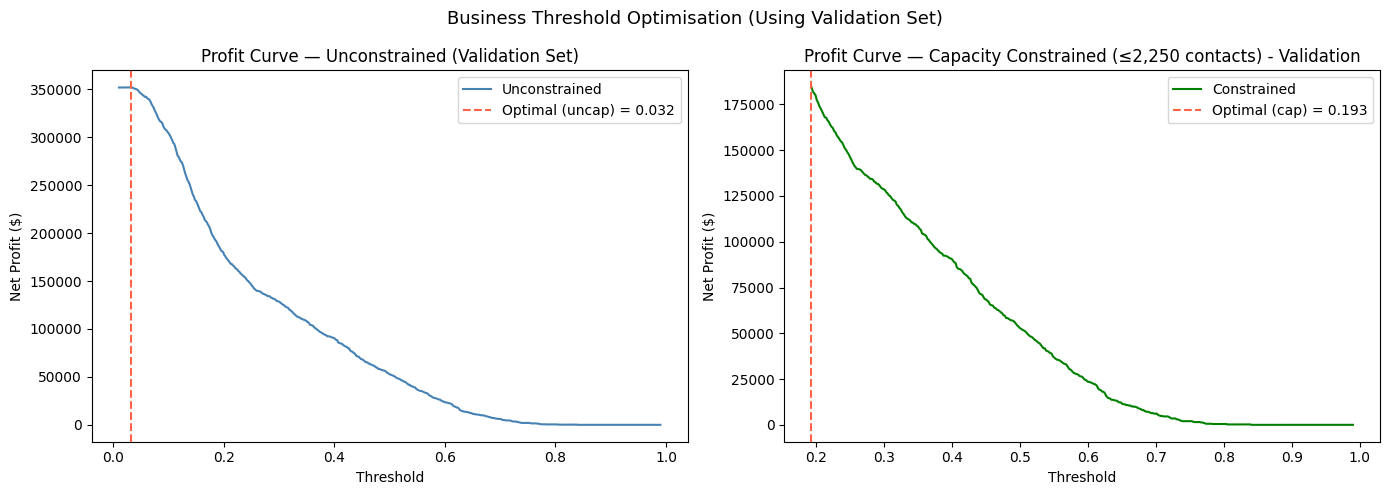

In [53]:
COST_CONTACT   = 5
BASE_VALUE_SAVED = 100
CLV_MULTIPLIER = 0.5 

customer_value_saved = BASE_VALUE_SAVED + (X_val['clv_score'].values * CLV_MULTIPLIER)

n_active      = len(y_val)
MAX_CONTACTS  = int(0.25 * len(y_val))  # 25% capacity cap

print(f"Validation set size:        {len(y_val):,}")
print(f"Max contacts allowed: {MAX_CONTACTS:,}  (25% capacity cap)")
print(f"True churners in validation: {(y_val==1).sum():,}")

y_prob_val = final_model.predict_proba(X_val_prep)[:, 1]

thresholds    = np.linspace(0.01, 0.99, 500)
profits_uncap = []
profits_cap   = []

for t in thresholds:
    y_flag   = (y_prob_val >= t).astype(int)
    tp_mask  = (y_flag == 1) & (y_val == 1)
    contacts = y_flag.sum()
    total_value_saved = customer_value_saved[tp_mask].sum()
    profit_uncap = total_value_saved - (contacts * COST_CONTACT)
    profits_uncap.append(profit_uncap)

    if contacts <= MAX_CONTACTS:
        profits_cap.append(profit_uncap)
    else:
        profits_cap.append(np.nan)  

profits_uncap = np.array(profits_uncap, dtype=float)
profits_cap   = np.array(profits_cap,   dtype=float)

best_idx_uncap    = np.argmax(profits_uncap)
best_thresh_uncap = thresholds[best_idx_uncap]
best_profit_uncap = profits_uncap[best_idx_uncap]

valid_mask        = ~np.isnan(profits_cap)
best_idx_cap      = np.nanargmax(profits_cap)
best_thresh_cap   = thresholds[best_idx_cap]
best_profit_cap   = profits_cap[best_idx_cap]

contacts_at_uncap = (y_prob_val >= best_thresh_uncap).sum()
contacts_at_cap   = (y_prob_val >= best_thresh_cap).sum()

print(f"  UNCONSTRAINED (naive):")
print(f"    Threshold : {best_thresh_uncap:.4f}")
print(f"    Contacts  : {contacts_at_uncap:,}  ({contacts_at_uncap/len(y_val)*100:.1f}% of customers) ← impractical")
print(f"    Profit    : ${best_profit_uncap:,.0f}")

print(f"\n  CAPACITY-CONSTRAINED (realistic, ≤{MAX_CONTACTS:,} contacts):")
print(f"    Threshold : {best_thresh_cap:.4f}")
print(f"    Contacts  : {contacts_at_cap:,}  ({contacts_at_cap/len(y_val)*100:.1f}% of customers)")
print(f"    Profit    : ${best_profit_cap:,.0f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(thresholds, profits_uncap, color='steelblue', label='Unconstrained')
ax1.axvline(best_thresh_uncap, color='tomato', linestyle='--',
            label=f'Optimal (uncap) = {best_thresh_uncap:.3f}')
ax1.set_xlabel('Threshold'); ax1.set_ylabel('Net Profit ($)')
ax1.set_title('Profit Curve — Unconstrained (Validation Set)')
ax1.legend()

ax2.plot(thresholds[valid_mask], profits_cap[valid_mask], color='green', label='Constrained')
ax2.axvline(best_thresh_cap, color='tomato', linestyle='--',
            label=f'Optimal (cap) = {best_thresh_cap:.3f}')
ax2.set_xlabel('Threshold'); ax2.set_ylabel('Net Profit ($)')
ax2.set_title(f'Profit Curve — Capacity Constrained (≤{MAX_CONTACTS:,} contacts) - Validation')
ax2.legend()

plt.suptitle('Business Threshold Optimisation (Using Validation Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [54]:
print(" Thresholds by recall target (capacity-constrained, using validation set):")
for target_recall in [0.40, 0.50, 0.60, 0.70, 0.80]:
    for t in np.linspace(0.99, 0.01, 1000):
        y_flag   = (y_prob_val >= t).astype(int)
        contacts = y_flag.sum()
        if contacts > MAX_CONTACTS:
            continue   
        tp_mask = (y_flag == 1) & (y_val == 1)
        tp      = tp_mask.sum()
        recall  = tp / (y_val == 1).sum()
        if recall >= target_recall:
            profit = customer_value_saved[tp_mask].sum() - contacts * COST_CONTACT
            prec   = tp / contacts if contacts > 0 else 0
            print(f"  {target_recall*100:.0f}% recall → threshold={t:.4f} → "
                  f"contacts={contacts:,} → precision={prec:.2f} → profit=${profit:,.0f}")
            break
    else:
        print(f"  {target_recall*100:.0f}% recall → not achievable within capacity cap")

selected_threshold = best_thresh_cap
y_pred_business    = (y_prob_final >= selected_threshold).astype(int)

tp_mask_final  = (y_pred_business == 1) & (y_test == 1)
tp_final       = tp_mask_final.sum()
contacts_final = y_pred_business.sum()
prec_final     = tp_final / contacts_final if contacts_final > 0 else 0
rec_final      = tp_final / (y_test == 1).sum()
total_value_saved_final = (BASE_VALUE_SAVED + (X_test['clv_score'].values * CLV_MULTIPLIER))[tp_mask_final].sum()

print(f"\n Selected threshold (from validation set): {selected_threshold:.4f}")
print(f"   Contacts on TEST set:  {contacts_final:,}  ({contacts_final/len(y_test)*100:.1f}% of customers)")
print(f"   Precision on TEST set: {prec_final:.3f}  (1 in {1/prec_final:.1f} contacts is a real churner)")
print(f"   Recall on TEST set:    {rec_final:.3f}  ({tp_final:,} of {(y_test==1).sum():,} churners caught)")
print(f"   Profit on TEST set:    ${total_value_saved_final - contacts_final * COST_CONTACT:,.0f}")

print("\nClassification report at business threshold (TEST set):")
print(classification_report(y_test, y_pred_business, target_names=['Stay', 'Churn']))

 Thresholds by recall target (capacity-constrained, using validation set):
  40% recall → threshold=0.2474 → contacts=1,486 → precision=0.39 → profit=$147,659
  50% recall → threshold=0.1934 → contacts=2,216 → precision=0.33 → profit=$183,266
  60% recall → not achievable within capacity cap
  70% recall → not achievable within capacity cap
  80% recall → not achievable within capacity cap

 Selected threshold (from validation set): 0.1926
   Contacts on TEST set:  2,251  (25.0% of customers)
   Precision on TEST set: 0.332  (1 in 3.0 contacts is a real churner)
   Recall on TEST set:    0.511  (748 of 1,464 churners caught)
   Profit on TEST set:    $185,866

Classification report at business threshold (TEST set):
              precision    recall  f1-score   support

        Stay       0.89      0.80      0.84      7536
       Churn       0.33      0.51      0.40      1464

    accuracy                           0.75      9000
   macro avg       0.61      0.66      0.62      9000
wei

In [55]:


from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV

print("  XGBOOST CHURN MODEL TUNING")

xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [0, 0.1, 1, 10]
}

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_search = RandomizedSearchCV(
    xgb_base, 
    xgb_param_grid,
    n_iter=50,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nFitting XGBoost randomized search...")
xgb_search.fit(X_train_prep, y_train)

print("\n")
print("BEST PARAMETERS FOUND:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV PR-AUC: {xgb_search.best_score_:.4f}")

  XGBOOST CHURN MODEL TUNING

Fitting XGBoost randomized search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


BEST PARAMETERS FOUND:
  subsample: 0.7
  reg_lambda: 0.1
  reg_alpha: 0.1
  n_estimators: 100
  min_child_weight: 1
  max_depth: 3
  learning_rate: 0.05
  colsample_bytree: 0.9

Best CV PR-AUC: 0.3789


In [56]:


print("\nTUNED + Calibrating XGBoost model - Final Test")
xgb_calibrated = CalibratedClassifierCV(
    xgb_search.best_estimator_,
    method='sigmoid',
    cv=5
)
xgb_calibrated.fit(X_train_prep, y_train)

y_pred_xgb = xgb_calibrated.predict(X_test_prep)
y_prob_xgb = xgb_calibrated.predict_proba(X_test_prep)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=['Stay', 'Churn']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob_xgb):.4f}")
print(f"Brier   : {brier_score_loss(y_test, y_prob_xgb):.4f}")

print(f"\nCalibration check:")
print(f"  True churn base rate   : {y_test.mean():.4f}")
print(f"  Mean predicted prob    : {y_prob_xgb.mean():.4f}")
print(f"  Gap                    : {abs(y_prob_xgb.mean() - y_test.mean()):.4f}")

xgb_results = {
    'model': xgb_calibrated,
    'y_pred': y_pred_xgb,
    'y_prob': y_prob_xgb,
    'auc': roc_auc_score(y_test, y_prob_xgb),
    'pr_auc': average_precision_score(y_test, y_prob_xgb),
    'brier': brier_score_loss(y_test, y_prob_xgb)
}


TUNED + Calibrating XGBoost model - Final Test
              precision    recall  f1-score   support

        Stay       0.85      0.98      0.91      7536
       Churn       0.57      0.11      0.19      1464

    accuracy                           0.84      9000
   macro avg       0.71      0.55      0.55      9000
weighted avg       0.80      0.84      0.79      9000

AUC-ROC : 0.7209
PR-AUC  : 0.3710
Brier   : 0.1214

Calibration check:
  True churn base rate   : 0.1627
  Mean predicted prob    : 0.1639
  Gap                    : 0.0012


In [57]:

print("  XGBOOST CHURN - BUSINESS THRESHOLD OPTIMIZATION")

y_prob_xgb_val = xgb_calibrated.predict_proba(X_val_prep)[:, 1]

customer_value_saved_val = BASE_VALUE_SAVED + (X_val['clv_score'].values * CLV_MULTIPLIER)

MAX_CONTACTS = int(0.25 * len(y_val))

print(f"Validation set size:        {len(y_val):,}")
print(f"Max contacts allowed: {MAX_CONTACTS:,}  (25% capacity cap)")
print(f"True churners in validation: {(y_val==1).sum():,}")

thresholds = np.linspace(0.01, 0.99, 500)
profits_xgb = []

for t in thresholds:
    y_flag = (y_prob_xgb_val >= t).astype(int)
    contacts = y_flag.sum()
    
    if contacts <= MAX_CONTACTS:
        tp_mask = (y_flag == 1) & (y_val == 1)
        total_value_saved = customer_value_saved_val[tp_mask].sum()
        profit = total_value_saved - (contacts * COST_CONTACT)
        profits_xgb.append(profit)
    else:
        profits_xgb.append(np.nan)

profits_xgb = np.array(profits_xgb, dtype=float)
valid_mask = ~np.isnan(profits_xgb)
best_idx_xgb = np.nanargmax(profits_xgb)
best_thresh_xgb = thresholds[best_idx_xgb]
best_profit_xgb = profits_xgb[best_idx_xgb]

contacts_at_opt = (y_prob_xgb_val >= best_thresh_xgb).sum()
tp_at_opt = ((y_prob_xgb_val >= best_thresh_xgb) & (y_val == 1)).sum()
precision_opt = tp_at_opt / contacts_at_opt if contacts_at_opt > 0 else 0
recall_opt = tp_at_opt / (y_val == 1).sum()

y_pred_xgb_biz = (y_prob_xgb >= best_thresh_xgb).astype(int)

tp_xgb_test = ((y_pred_xgb_biz == 1) & (y_test == 1)).sum()
contacts_xgb_test = y_pred_xgb_biz.sum()
prec_xgb_test = tp_xgb_test / contacts_xgb_test if contacts_xgb_test > 0 else 0
rec_xgb_test = tp_xgb_test / (y_test == 1).sum()
customer_value_saved_test = BASE_VALUE_SAVED + (X_test['clv_score'].values * CLV_MULTIPLIER)
profit_xgb_test = customer_value_saved_test[(y_pred_xgb_biz == 1) & (y_test == 1)].sum() - contacts_xgb_test * COST_CONTACT

print(f"\nXGBOOST PERFORMANCE ON TEST SET with optimal threshold:")
print(f"  Selected threshold (from validation set): {best_thresh_xgb:.4f}")
print(f"  Contacts:  {contacts_xgb_test:,} ({contacts_xgb_test/len(y_test)*100:.1f}% of test customers)")
print(f"  Precision: {prec_xgb_test:.3f}")
print(f"  Recall:    {rec_xgb_test:.3f}")
print(f"  Profit:    ${profit_xgb_test:,.0f}")

print("\nClassification report at business threshold (TEST set):")
print(classification_report(y_test, y_pred_xgb_biz, target_names=['Stay', 'Churn']))

  XGBOOST CHURN - BUSINESS THRESHOLD OPTIMIZATION
Validation set size:        9,000
Max contacts allowed: 2,250  (25% capacity cap)
True churners in validation: 1,465

XGBOOST PERFORMANCE ON TEST SET with optimal threshold:
  Selected threshold (from validation set): 0.1985
  Contacts:  2,267 (25.2% of test customers)
  Precision: 0.335
  Recall:    0.518
  Profit:    $187,737

Classification report at business threshold (TEST set):
              precision    recall  f1-score   support

        Stay       0.90      0.80      0.84      7536
       Churn       0.33      0.52      0.41      1464

    accuracy                           0.75      9000
   macro avg       0.62      0.66      0.63      9000
weighted avg       0.80      0.75      0.77      9000



In [ ]:
print("  SVM CHURN MODEL TUNING")

svm_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'loss': ['hinge', 'squared_hinge'],
    'class_weight': ['balanced'],
}

svm_base = LinearSVC(
    random_state=42,
    max_iter=5000,
    dual='auto'
)

svm_search = RandomizedSearchCV(
    svm_base,
    svm_param_grid,
    n_iter=8,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nFitting Linear SVM randomized search for churn...")
svm_search.fit(X_train_prep, y_train)

print("\nBEST PARAMETERS FOUND:")
for k, v in svm_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV PR-AUC: {svm_search.best_score_:.4f}")


In [ ]:
print("\nTUNED + Calibrating Linear SVM model - Final Test")
svm_calibrated = CalibratedClassifierCV(
    svm_search.best_estimator_,
    method='sigmoid',
    cv=5
)
svm_calibrated.fit(X_train_prep, y_train)

y_pred_svm = svm_calibrated.predict(X_test_prep)
y_prob_svm = svm_calibrated.predict_proba(X_test_prep)[:, 1]

print(classification_report(y_test, y_pred_svm, target_names=['Stay', 'Churn']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_svm):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob_svm):.4f}")
print(f"Brier   : {brier_score_loss(y_test, y_prob_svm):.4f}")

print(f"\nCalibration check:") 
print(f"  True churn base rate   : {y_test.mean():.4f}")
print(f"  Mean predicted prob    : {y_prob_svm.mean():.4f}")
print(f"  Gap                    : {abs(y_prob_svm.mean() - y_test.mean()):.4f}")

results['Linear SVM (Tuned + Calibrated)'] = {
    'model': svm_calibrated,
    'y_pred': y_pred_svm,
    'y_prob': y_prob_svm,
    'auc': roc_auc_score(y_test, y_prob_svm),
    'pr_auc': average_precision_score(y_test, y_prob_svm),
    'brier': brier_score_loss(y_test, y_prob_svm)
}


In [ ]:
print("  SVM CHURN - BUSINESS THRESHOLD OPTIMIZATION")

y_prob_svm_val = svm_calibrated.predict_proba(X_val_prep)[:, 1]
customer_value_saved_svm_val = BASE_VALUE_SAVED + (X_val['clv_score'].values * CLV_MULTIPLIER)
MAX_CONTACTS = int(0.25 * len(y_val))

thresholds = np.linspace(0.01, 0.99, 500)
profits_svm = []

for t in thresholds:
    y_flag = (y_prob_svm_val >= t).astype(int)
    contacts = y_flag.sum()
    if contacts <= MAX_CONTACTS:
        tp_mask = (y_flag == 1) & (y_val == 1)
        total_value_saved = customer_value_saved_svm_val[tp_mask].sum()
        profit = total_value_saved - (contacts * COST_CONTACT)
        profits_svm.append(profit)
    else:
        profits_svm.append(np.nan)

profits_svm = np.array(profits_svm, dtype=float)
best_idx_svm = np.nanargmax(profits_svm)
best_thresh_svm = thresholds[best_idx_svm]
best_profit_svm = profits_svm[best_idx_svm]

y_pred_svm_biz = (y_prob_svm >= best_thresh_svm).astype(int)

svm_tp_test = ((y_pred_svm_biz == 1) & (y_test == 1)).sum()
svm_contacts_test = y_pred_svm_biz.sum()
svm_precision_test = svm_tp_test / svm_contacts_test if svm_contacts_test > 0 else 0
svm_recall_test = svm_tp_test / (y_test == 1).sum()
customer_value_saved_test = BASE_VALUE_SAVED + (X_test['clv_score'].values * CLV_MULTIPLIER)
profit_svm_test = customer_value_saved_test[(y_pred_svm_biz == 1) & (y_test == 1)].sum() - svm_contacts_test * COST_CONTACT

print(f"\nSVM CHURN PERFORMANCE ON TEST SET:")
print(f"  Selected threshold (from validation set): {best_thresh_svm:.4f}")
print(f"  Contacts:  {svm_contacts_test:,} ({svm_contacts_test/len(y_test)*100:.1f}% of test customers)")
print(f"  Precision: {svm_precision_test:.3f}")
print(f"  Recall:    {svm_recall_test:.3f}")
print(f"  Profit:    ${profit_svm_test:,.0f}")

print("\nClassification report at business threshold (TEST set):")
print(classification_report(y_test, y_pred_svm_biz, target_names=['Stay', 'Churn']))


In [59]:


print("  CROSS-SELL DATA PREPARATION")
df_cs = df[df['churned'] == 0].copy()

CS_DROP = [
    'customer_id', 'churned',
    'clv_segment', 'risk_segment',
    'internet_banking_logins_monthly',
    'mobile_app_logins_monthly',
]

df_cs = df_cs.drop(columns=CS_DROP)

print(f'Cross-sell dataset: {df_cs.shape}')
print(f'Acceptance rate: {df_cs["cross_sell_accepted"].mean():.3f}  '
      f'({df_cs["cross_sell_accepted"].sum():,} accepted)')

df_cs = engineer_features(df_cs)

X_cs = df_cs.drop(columns=['cross_sell_accepted'])
y_cs = df_cs['cross_sell_accepted']

X_cs_train, X_cs_temp, y_cs_train, y_cs_temp = train_test_split(
    X_cs, y_cs, test_size=0.3, stratify=y_cs, random_state=42
)
X_cs_val, X_cs_test, y_cs_val, y_cs_test = train_test_split(
    X_cs_temp, y_cs_temp, test_size=0.5, stratify=y_cs_temp, random_state=42
)

cs_preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('ord', ordinal_pipeline, list(ordinal_cols_map.keys())),
    ('nom', nominal_pipeline, nominal_cols),
], remainder='drop')

X_cs_train_prep = cs_preprocessor.fit_transform(X_cs_train)
X_cs_val_prep = cs_preprocessor.transform(X_cs_val)
X_cs_test_prep = cs_preprocessor.transform(X_cs_test)

imbalance_ratio = (y_cs_train == 0).sum() / (y_cs_train == 1).sum()
print(f'\nCross-sell imbalance ratio: {imbalance_ratio:.2f}')
print(f'CS Train: {X_cs_train_prep.shape} | CS Val: {X_cs_val_prep.shape} | CS Test: {X_cs_test_prep.shape}')

  CROSS-SELL DATA PREPARATION
Cross-sell dataset: (50238, 38)
Acceptance rate: 0.288  (14,458 accepted)

Cross-sell imbalance ratio: 2.47
CS Train: (35166, 59) | CS Val: (7536, 59) | CS Test: (7536, 59)


In [60]:

print("  CROSS-SELL BASE MODEL (Logistic Regression)")

cs_base_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

cs_base_model.fit(X_cs_train_prep, y_cs_train)

y_cs_pred_base = cs_base_model.predict(X_cs_test_prep)
y_cs_prob_base = cs_base_model.predict_proba(X_cs_test_prep)[:, 1]

print("BASE MODEL PERFORMANCE (NO TUNING)")
print(classification_report(y_cs_test, y_cs_pred_base, target_names=['Not Accepted', 'Accepted']))
print(f"AUC-ROC : {roc_auc_score(y_cs_test, y_cs_prob_base):.4f}")
print(f"PR-AUC  : {average_precision_score(y_cs_test, y_cs_prob_base):.4f}")
print(f"Brier   : {brier_score_loss(y_cs_test, y_cs_prob_base):.4f}")

print(f"\nCalibration check:")
print(f"  True acceptance rate   : {y_cs_test.mean():.4f}")
print(f"  Mean predicted prob    : {y_cs_prob_base.mean():.4f}")
print(f"  Gap                    : {abs(y_cs_prob_base.mean() - y_cs_test.mean()):.4f}")

  CROSS-SELL BASE MODEL (Logistic Regression)
BASE MODEL PERFORMANCE (NO TUNING)
              precision    recall  f1-score   support

Not Accepted       0.78      0.57      0.66      5367
    Accepted       0.36      0.61      0.46      2169

    accuracy                           0.58      7536
   macro avg       0.57      0.59      0.56      7536
weighted avg       0.66      0.58      0.60      7536

AUC-ROC : 0.6275
PR-AUC  : 0.3882
Brier   : 0.2373

Calibration check:
  True acceptance rate   : 0.2878
  Mean predicted prob    : 0.4875
  Gap                    : 0.1997


In [61]:

print("  CROSS-SELL MODEL TUNING")

lr_cs_params = {
    'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'max_iter': [1000]
}

lr_cs_base = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

lr_cs_search = RandomizedSearchCV(
    lr_cs_base, lr_cs_params,
    n_iter=15,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nFitting Logistic Regression for cross-sell...")
lr_cs_search.fit(X_cs_train_prep, y_cs_train)

print("BEST PARAMETERS FOUND:")
for k, v in lr_cs_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV PR-AUC: {lr_cs_search.best_score_:.4f}")

  CROSS-SELL MODEL TUNING

Fitting Logistic Regression for cross-sell...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


BEST PARAMETERS FOUND:
  solver: liblinear
  penalty: l1
  max_iter: 1000
  C: 0.01

Best CV PR-AUC: 0.3978


In [63]:


print("\nTUNED + Calibrating cross-sell model + Final Test")
cs_model = CalibratedClassifierCV(
    lr_cs_search.best_estimator_,
    method='sigmoid',
    cv=5
)
cs_model.fit(X_cs_train_prep, y_cs_train)

y_cs_prob = cs_model.predict_proba(X_cs_test_prep)[:, 1]
y_cs_pred = cs_model.predict(X_cs_test_prep)

cs_pr_auc = average_precision_score(y_cs_test, y_cs_prob)
cs_roc_auc = roc_auc_score(y_cs_test, y_cs_prob)
cs_brier = brier_score_loss(y_cs_test, y_cs_prob)

print(classification_report(y_cs_test, y_cs_pred, target_names=['Not Accepted', 'Accepted']))
print(f"AUC-ROC : {cs_roc_auc:.4f}")
print(f"PR-AUC  : {cs_pr_auc:.4f}  <- primary metric")
print(f"Brier   : {cs_brier:.4f}")

print(f"\nCalibration check:")
print(f"  True acceptance rate   : {y_cs_test.mean():.4f}")
print(f"  Mean predicted prob    : {y_cs_prob.mean():.4f}")
print(f"  Gap                    : {abs(y_cs_prob.mean() - y_cs_test.mean()):.4f}")


TUNED + Calibrating cross-sell model + Final Test
              precision    recall  f1-score   support

Not Accepted       0.72      0.99      0.83      5367
    Accepted       0.54      0.02      0.05      2169

    accuracy                           0.71      7536
   macro avg       0.63      0.51      0.44      7536
weighted avg       0.67      0.71      0.61      7536

AUC-ROC : 0.6301
PR-AUC  : 0.3935  <- primary metric
Brier   : 0.1961

Calibration check:
  True acceptance rate   : 0.2878
  Mean predicted prob    : 0.2878
  Gap                    : 0.0000


In [ ]:
print("  XGBOOST CROSS-SELL MODEL TUNING")

xgb_cs_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [0, 0.1, 1, 10]
}

scale_pos_cs = (y_cs_train == 0).sum() / (y_cs_train == 1).sum()

xgb_cs_base = XGBClassifier(
    scale_pos_weight=scale_pos_cs,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_cs_search = RandomizedSearchCV(
    xgb_cs_base,
    xgb_cs_param_grid,
    n_iter=50,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nFitting XGBoost randomized search for cross-sell...")
xgb_cs_search.fit(X_cs_train_prep, y_cs_train)

print("\nBEST PARAMETERS FOUND:")
for k, v in xgb_cs_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV PR-AUC: {xgb_cs_search.best_score_:.4f}")


In [ ]:
print("\nTUNED + Calibrating cross-sell XGBoost - Final Test")

cs_xgb_model = CalibratedClassifierCV(
    xgb_cs_search.best_estimator_,
    method='sigmoid',
    cv=5
)
cs_xgb_model.fit(X_cs_train_prep, y_cs_train)

y_cs_prob_xgb = cs_xgb_model.predict_proba(X_cs_test_prep)[:, 1]
y_cs_pred_xgb = cs_xgb_model.predict(X_cs_test_prep)

cs_xgb_pr_auc = average_precision_score(y_cs_test, y_cs_prob_xgb)
cs_xgb_roc_auc = roc_auc_score(y_cs_test, y_cs_prob_xgb)
cs_xgb_brier = brier_score_loss(y_cs_test, y_cs_prob_xgb)

print(classification_report(y_cs_test, y_cs_pred_xgb, target_names=['Not Accepted', 'Accepted']))
print(f"AUC-ROC : {cs_xgb_roc_auc:.4f}")
print(f"PR-AUC  : {cs_xgb_pr_auc:.4f}  <- primary metric")
print(f"Brier   : {cs_xgb_brier:.4f}")

print(f"\nCalibration check:")
print(f"  True acceptance rate   : {y_cs_test.mean():.4f}")
print(f"  Mean predicted prob    : {y_cs_prob_xgb.mean():.4f}")
print(f"  Gap                    : {abs(y_cs_prob_xgb.mean() - y_cs_test.mean()):.4f}")


In [ ]:
REVENUE_PER_ACCEPT = 200
COST_PER_CONTACT = 5
MAX_CS_CONTACTS = int(0.30 * len(y_cs_val))

print("  XGBOOST CROSS-SELL BUSINESS THRESHOLD OPTIMIZATION")

print(f"\nBusiness settings:")
print(f"  Revenue per acceptance: ${REVENUE_PER_ACCEPT}")
print(f"  Cost per contact:       ${COST_PER_CONTACT}")
print(f"  Max contacts (validation): {MAX_CS_CONTACTS:,} (30% capacity)")

y_cs_prob_xgb_val = cs_xgb_model.predict_proba(X_cs_val_prep)[:, 1]

cs_xgb_thresholds = np.linspace(0.01, 0.99, 500)
cs_xgb_profits = []

for t in cs_xgb_thresholds:
    y_flag = (y_cs_prob_xgb_val >= t).astype(int)
    contacts = y_flag.sum()
    
    if contacts <= MAX_CS_CONTACTS:
        tp = ((y_flag == 1) & (y_cs_val == 1)).sum()
        profit = tp * REVENUE_PER_ACCEPT - contacts * COST_PER_CONTACT
        cs_xgb_profits.append(profit)
    else:
        cs_xgb_profits.append(np.nan)

cs_xgb_profits = np.array(cs_xgb_profits, dtype=float)
best_idx_cs_xgb = np.nanargmax(cs_xgb_profits)
best_cs_xgb_thresh = cs_xgb_thresholds[best_idx_cs_xgb]
best_cs_xgb_profit = cs_xgb_profits[best_idx_cs_xgb]

print(f"\nOPTIMAL THRESHOLD (from validation set): {best_cs_xgb_thresh:.4f}")

# Apply to test set
y_cs_pred_xgb_biz = (y_cs_prob_xgb >= best_cs_xgb_thresh).astype(int)

cs_xgb_tp_test = ((y_cs_pred_xgb_biz == 1) & (y_cs_test == 1)).sum()
cs_xgb_contacts_test = y_cs_pred_xgb_biz.sum()
cs_xgb_precision_test = cs_xgb_tp_test / cs_xgb_contacts_test if cs_xgb_contacts_test > 0 else 0
cs_xgb_recall_test = cs_xgb_tp_test / y_cs_test.sum()
cs_xgb_profit_test = cs_xgb_tp_test * REVENUE_PER_ACCEPT - cs_xgb_contacts_test * COST_PER_CONTACT

print(f"\nXGBOOST CROSS-SELL PERFORMANCE ON TEST SET:")
print(f"   Contacts:  {cs_xgb_contacts_test:,} ({cs_xgb_contacts_test/len(y_cs_test)*100:.1f}% of customers)")
print(f"   Precision: {cs_xgb_precision_test:.3f} (1 in {1/cs_xgb_precision_test:.1f} contacts buys)")
print(f"   Recall:    {cs_xgb_recall_test:.3f} ({cs_xgb_tp_test:,} of {y_cs_test.sum():,} buyers caught)")
print(f"   Profit:    ${cs_xgb_profit_test:,.0f}")

print("\nClassification report at business threshold (TEST set):")
print(classification_report(y_cs_test, y_cs_pred_xgb_biz, target_names=['Not Accepted', 'Accepted']))


In [ ]:
print("  SVM CROSS-SELL MODEL TUNING")

svm_cs_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'loss': ['hinge', 'squared_hinge'],
    'class_weight': ['balanced'],
}

svm_cs_base = LinearSVC(
    random_state=42,
    max_iter=5000,
    dual='auto'
)

svm_cs_search = RandomizedSearchCV(
    svm_cs_base,
    svm_cs_param_grid,
    n_iter=8,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nFitting Linear SVM randomized search for cross-sell...")
svm_cs_search.fit(X_cs_train_prep, y_cs_train)

print("\nBEST PARAMETERS FOUND:")
for k, v in svm_cs_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV PR-AUC: {svm_cs_search.best_score_:.4f}")


In [ ]:
print("\nTUNED + Calibrating cross-sell Linear SVM - Final Test")
cs_svm_model = CalibratedClassifierCV(
    svm_cs_search.best_estimator_,
    method='sigmoid',
    cv=5
)
cs_svm_model.fit(X_cs_train_prep, y_cs_train)

y_cs_prob_svm = cs_svm_model.predict_proba(X_cs_test_prep)[:, 1]
y_cs_pred_svm = cs_svm_model.predict(X_cs_test_prep)

print(classification_report(y_cs_test, y_cs_pred_svm, target_names=['Not Accepted', 'Accepted']))
print(f"AUC-ROC : {roc_auc_score(y_cs_test, y_cs_prob_svm):.4f}")
print(f"PR-AUC  : {average_precision_score(y_cs_test, y_cs_prob_svm):.4f}")
print(f"Brier   : {brier_score_loss(y_cs_test, y_cs_prob_svm):.4f}")

print(f"\nCalibration check:")
print(f"  True acceptance rate   : {y_cs_test.mean():.4f}")
print(f"  Mean predicted prob    : {y_cs_prob_svm.mean():.4f}")
print(f"  Gap                    : {abs(y_cs_prob_svm.mean() - y_cs_test.mean()):.4f}")


In [ ]:
REVENUE_PER_ACCEPT = 200
COST_PER_CONTACT = 5
MAX_CS_CONTACTS = int(0.30 * len(y_cs_val))

print("  SVM CROSS-SELL BUSINESS THRESHOLD OPTIMIZATION")

y_cs_prob_svm_val = cs_svm_model.predict_proba(X_cs_val_prep)[:, 1]

cs_svm_thresholds = np.linspace(0.01, 0.99, 500)
cs_svm_profits = []

for t in cs_svm_thresholds:
    y_flag = (y_cs_prob_svm_val >= t).astype(int)
    contacts = y_flag.sum()
    if contacts <= MAX_CS_CONTACTS:
        tp = ((y_flag == 1) & (y_cs_val == 1)).sum()
        profit = tp * REVENUE_PER_ACCEPT - contacts * COST_PER_CONTACT
        cs_svm_profits.append(profit)
    else:
        cs_svm_profits.append(np.nan)

cs_svm_profits = np.array(cs_svm_profits, dtype=float)
best_idx_cs_svm = np.nanargmax(cs_svm_profits)
best_cs_svm_thresh = cs_svm_thresholds[best_idx_cs_svm]
best_cs_svm_profit = cs_svm_profits[best_idx_cs_svm]

y_cs_pred_svm_biz = (y_cs_prob_svm >= best_cs_svm_thresh).astype(int)

cs_svm_tp_test = ((y_cs_pred_svm_biz == 1) & (y_cs_test == 1)).sum()
cs_svm_contacts_test = y_cs_pred_svm_biz.sum()
cs_svm_precision_test = cs_svm_tp_test / cs_svm_contacts_test if cs_svm_contacts_test > 0 else 0
cs_svm_recall_test = cs_svm_tp_test / y_cs_test.sum()
cs_svm_profit_test = cs_svm_tp_test * REVENUE_PER_ACCEPT - cs_svm_contacts_test * COST_PER_CONTACT

print(f"\nSVM CROSS-SELL PERFORMANCE ON TEST SET:")
print(f"   Selected threshold: {best_cs_svm_thresh:.4f}")
print(f"   Contacts:  {cs_svm_contacts_test:,} ({cs_svm_contacts_test/len(y_cs_test)*100:.1f}% of customers)")
print(f"   Precision: {cs_svm_precision_test:.3f}")
print(f"   Recall:    {cs_svm_recall_test:.3f}")
print(f"   Profit:    ${cs_svm_profit_test:,.0f}")

print("\nClassification report at business threshold (TEST set):")
print(classification_report(y_cs_test, y_cs_pred_svm_biz, target_names=['Not Accepted', 'Accepted']))


In [64]:

REVENUE_PER_ACCEPT = 200
COST_PER_CONTACT = 5
MAX_CS_CONTACTS = int(0.30 * len(y_cs_val))

print("  CROSS-SELL BUSINESS THRESHOLD OPTIMIZATION")

print(f"\nBusiness settings:")
print(f"  Revenue per acceptance: ${REVENUE_PER_ACCEPT}")
print(f"  Cost per contact:       ${COST_PER_CONTACT}")
print(f"  Max contacts (validation): {MAX_CS_CONTACTS:,} (30% capacity)")

y_cs_prob_val = cs_model.predict_proba(X_cs_val_prep)[:, 1]

cs_thresholds = np.linspace(0.01, 0.99, 500)
cs_profits = []

for t in cs_thresholds:
    y_flag = (y_cs_prob_val >= t).astype(int)
    contacts = y_flag.sum()
    
    if contacts <= MAX_CS_CONTACTS:
        tp = ((y_flag == 1) & (y_cs_val == 1)).sum()
        profit = tp * REVENUE_PER_ACCEPT - contacts * COST_PER_CONTACT
        cs_profits.append(profit)
    else:
        cs_profits.append(np.nan)

cs_profits = np.array(cs_profits, dtype=float)
best_idx = np.nanargmax(cs_profits)
best_cs_thresh = cs_thresholds[best_idx]
best_cs_profit = cs_profits[best_idx]

print(f"\nOPTIMAL THRESHOLD (from validation set): {best_cs_thresh:.4f}")

# Apply to test set
y_cs_pred_biz = (y_cs_prob >= best_cs_thresh).astype(int)

cs_tp_test = ((y_cs_pred_biz == 1) & (y_cs_test == 1)).sum()
cs_contacts_test = y_cs_pred_biz.sum()
cs_precision_test = cs_tp_test / cs_contacts_test if cs_contacts_test > 0 else 0
cs_recall_test = cs_tp_test / y_cs_test.sum()
cs_profit_test = cs_tp_test * REVENUE_PER_ACCEPT - cs_contacts_test * COST_PER_CONTACT

print(f"\nCROSS-SELL PERFORMANCE ON TEST SET:")
print(f"   Contacts:  {cs_contacts_test:,} ({cs_contacts_test/len(y_cs_test)*100:.1f}% of customers)")
print(f"   Precision: {cs_precision_test:.3f} (1 in {1/cs_precision_test:.1f} contacts buys)")
print(f"   Recall:    {cs_recall_test:.3f} ({cs_tp_test:,} of {y_cs_test.sum():,} buyers caught)")
print(f"   Profit:    ${cs_profit_test:,.0f}")

print("\nClassification report at business threshold (TEST set):")
print(classification_report(y_cs_test, y_cs_pred_biz, target_names=['Not Accepted', 'Accepted']))

  CROSS-SELL BUSINESS THRESHOLD OPTIMIZATION

Business settings:
  Revenue per acceptance: $200
  Cost per contact:       $5
  Max contacts (validation): 2,260 (30% capacity)

OPTIMAL THRESHOLD (from validation set): 0.3399

CROSS-SELL PERFORMANCE ON TEST SET:
   Contacts:  2,189 (29.0% of customers)
   Precision: 0.404 (1 in 2.5 contacts buys)
   Recall:    0.408 (885 of 2,169 buyers caught)
   Profit:    $166,055

Classification report at business threshold (TEST set):
              precision    recall  f1-score   support

Not Accepted       0.76      0.76      0.76      5367
    Accepted       0.40      0.41      0.41      2169

    accuracy                           0.66      7536
   macro avg       0.58      0.58      0.58      7536
weighted avg       0.66      0.66      0.66      7536



In [ ]:
print("  FINAL MODEL SELECTION BY BUSINESS PROFIT")

# Churn models are selected using TEST profit after validation-threshold optimization.
churn_model_results = {
    'Logistic Regression': {
        'model': churn_lr_model,
        'threshold': float(selected_threshold),
        'test_profit': float(total_value_saved_final - contacts_final * COST_CONTACT),
        'test_precision': float(prec_final),
        'test_recall': float(rec_final),
        'test_contacts': int(contacts_final),
        'test_prob': y_prob_final,
        'val_prob': y_prob_val,
        'test_pred_business': y_pred_business,
    },
    'XGBoost': {
        'model': xgb_calibrated,
        'threshold': float(best_thresh_xgb),
        'test_profit': float(profit_xgb_test),
        'test_precision': float(prec_xgb_test),
        'test_recall': float(rec_xgb_test),
        'test_contacts': int(contacts_xgb_test),
        'test_prob': y_prob_xgb,
        'val_prob': y_prob_xgb_val,
        'test_pred_business': y_pred_xgb_biz,
    },
    'Linear SVM': {
        'model': svm_calibrated,
        'threshold': float(best_thresh_svm),
        'test_profit': float(profit_svm_test),
        'test_precision': float(svm_precision_test),
        'test_recall': float(svm_recall_test),
        'test_contacts': int(svm_contacts_test),
        'test_prob': y_prob_svm,
        'val_prob': y_prob_svm_val,
        'test_pred_business': y_pred_svm_biz,
    },
}

churn_selection_table = pd.DataFrame(churn_model_results).T.sort_values('test_profit', ascending=False)
print("\nChurn model comparison after business threshold optimization:")
print(churn_selection_table[['threshold', 'test_contacts', 'test_precision', 'test_recall', 'test_profit']])

best_churn_name = churn_selection_table.index[0]
best_churn = churn_model_results[best_churn_name]
final_model = best_churn['model']
selected_threshold = best_churn['threshold']
y_prob_final = best_churn['test_prob']
y_pred_business = best_churn['test_pred_business']

print(f"\nSelected churn model: {best_churn_name}")
print(f"Selected churn threshold: {selected_threshold:.4f}")

# Cross-sell models are selected using TEST profit after validation-threshold optimization.
cs_model_results = {
    'Logistic Regression': {
        'model': cs_model,
        'threshold': float(best_cs_thresh),
        'test_profit': float(cs_profit_test),
        'test_precision': float(cs_precision_test),
        'test_recall': float(cs_recall_test),
        'test_contacts': int(cs_contacts_test),
        'test_prob': y_cs_prob,
        'val_prob': y_cs_prob_val,
        'test_pred_business': y_cs_pred_biz,
    },
    'XGBoost': {
        'model': cs_xgb_model,
        'threshold': float(best_cs_xgb_thresh),
        'test_profit': float(cs_xgb_profit_test),
        'test_precision': float(cs_xgb_precision_test),
        'test_recall': float(cs_xgb_recall_test),
        'test_contacts': int(cs_xgb_contacts_test),
        'test_prob': y_cs_prob_xgb,
        'val_prob': y_cs_prob_xgb_val,
        'test_pred_business': y_cs_pred_xgb_biz,
    },
    'Linear SVM': {
        'model': cs_svm_model,
        'threshold': float(best_cs_svm_thresh),
        'test_profit': float(cs_svm_profit_test),
        'test_precision': float(cs_svm_precision_test),
        'test_recall': float(cs_svm_recall_test),
        'test_contacts': int(cs_svm_contacts_test),
        'test_prob': y_cs_prob_svm,
        'val_prob': y_cs_prob_svm_val,
        'test_pred_business': y_cs_pred_svm_biz,
    },
}

cs_selection_table = pd.DataFrame(cs_model_results).T.sort_values('test_profit', ascending=False)
print("\nCross-sell model comparison after business threshold optimization:")
print(cs_selection_table[['threshold', 'test_contacts', 'test_precision', 'test_recall', 'test_profit']])

best_cs_name = cs_selection_table.index[0]
best_cs = cs_model_results[best_cs_name]
cs_model = best_cs['model']
best_cs_thresh = best_cs['threshold']
y_cs_prob = best_cs['test_prob']
y_cs_pred_biz = best_cs['test_pred_business']

print(f"\nSelected cross-sell model: {best_cs_name}")
print(f"Selected cross-sell threshold: {best_cs_thresh:.4f}")


In [ ]:
print("  FINAL SELECTED MODEL SHAP ANALYSIS")

# Build feature names after preprocessing.
ohe_feature_names = (
    preprocessor.named_transformers_['nom']['encode']
    .get_feature_names_out(nominal_cols)
    .tolist()
)
all_feature_names = numeric_cols + list(ordinal_cols_map.keys()) + ohe_feature_names
X_val_df = pd.DataFrame(X_val_prep, columns=all_feature_names)

print(f"Selected churn model for SHAP: {best_churn_name}")
print(f"Feature matrix shape: {X_val_df.shape}")

if best_churn_name == 'XGBoost':
    shap_model = xgb_search.best_estimator_
    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_val_df)
    expected_value = explainer.expected_value
elif best_churn_name == 'Logistic Regression':
    shap_model = lr_search.best_estimator_
    masker = shap.maskers.Independent(X_val_df, max_samples=len(X_val_df))
    explainer = shap.LinearExplainer(shap_model, masker)
    shap_values = explainer.shap_values(X_val_df)
    expected_value = explainer.expected_value
else:
    shap_model = svm_search.best_estimator_
    masker = shap.maskers.Independent(X_val_df, max_samples=len(X_val_df))
    explainer = shap.LinearExplainer(shap_model, masker)
    shap_values = explainer.shap_values(X_val_df)
    expected_value = explainer.expected_value

print('Churn SHAP values computed.')

shap.summary_plot(shap_values, X_val_df, plot_type='bar', max_display=15, show=False)
plt.title(f'Top 15 Features - Mean |SHAP| Value ({best_churn_name})')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_val_df, max_display=15, show=False)
plt.title(f'SHAP Beeswarm - Feature Impact Direction ({best_churn_name})')
plt.tight_layout()
plt.show()

customer_idx = 0
shap.waterfall_plot(shap.Explanation(
    values=shap_values[customer_idx],
    base_values=expected_value,
    data=X_val_df.iloc[customer_idx],
    feature_names=all_feature_names
))

# Cross-sell SHAP for selected model.
ohe_feature_names_cs = (
    cs_preprocessor.named_transformers_['nom']['encode']
    .get_feature_names_out(nominal_cols)
    .tolist()
)
cs_feature_names = numeric_cols + list(ordinal_cols_map.keys()) + ohe_feature_names_cs
X_cs_val_df = pd.DataFrame(X_cs_val_prep, columns=cs_feature_names)

print(f"\nSelected cross-sell model for SHAP: {best_cs_name}")
print(f"Cross-sell feature matrix shape: {X_cs_val_df.shape}")

if best_cs_name == 'XGBoost':
    shap_model_cs = xgb_cs_search.best_estimator_
    explainer_cs = shap.TreeExplainer(shap_model_cs)
    shap_values_cs = explainer_cs.shap_values(X_cs_val_df)
    expected_value_cs = explainer_cs.expected_value
elif best_cs_name == 'Logistic Regression':
    shap_model_cs = lr_cs_search.best_estimator_
    masker_cs = shap.maskers.Independent(X_cs_val_df, max_samples=len(X_cs_val_df))
    explainer_cs = shap.LinearExplainer(shap_model_cs, masker_cs)
    shap_values_cs = explainer_cs.shap_values(X_cs_val_df)
    expected_value_cs = explainer_cs.expected_value
else:
    shap_model_cs = svm_cs_search.best_estimator_
    masker_cs = shap.maskers.Independent(X_cs_val_df, max_samples=len(X_cs_val_df))
    explainer_cs = shap.LinearExplainer(shap_model_cs, masker_cs)
    shap_values_cs = explainer_cs.shap_values(X_cs_val_df)
    expected_value_cs = explainer_cs.expected_value

print('Cross-sell SHAP values computed.')

shap.summary_plot(shap_values_cs, X_cs_val_df, plot_type='bar', max_display=15, show=False)
plt.title(f'Top 15 Features - Mean |SHAP| Value Cross-Sell ({best_cs_name})')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_cs, X_cs_val_df, max_display=15, show=False)
plt.title(f'SHAP Beeswarm - Feature Impact Direction Cross-Sell ({best_cs_name})')
plt.tight_layout()
plt.show()

shap.waterfall_plot(shap.Explanation(
    values=shap_values_cs[customer_idx],
    base_values=expected_value_cs,
    data=X_cs_val_df.iloc[customer_idx],
    feature_names=cs_feature_names
))


In [ ]:
print("  FINAL SCORE DISTRIBUTION AND SEGMENTATION")

# Churn scoring for all customers using selected final churn model.
df_score = df.drop(columns=DROP_COLS + ['cross_sell_accepted', 'churned']).copy()
df_score = engineer_features(df_score)
report = df[['customer_id', 'churned', 'cross_sell_accepted', 'clv_segment']].copy()
report['churn_prob'] = final_model.predict_proba(df_score)[:, 1]

p33 = report['churn_prob'].quantile(0.33)
p66 = report['churn_prob'].quantile(0.66)
risk_band_edges = [0.0, float(p33), float(p66), 1.0]

print(f"Churn score distribution ({best_churn_name}):")
print(f"  Min:    {report['churn_prob'].min():.4f}")
print(f"  P33:    {p33:.4f}  Low/Medium boundary")
print(f"  Median: {report['churn_prob'].median():.4f}")
print(f"  P66:    {p66:.4f}  Medium/High boundary")
print(f"  Max:    {report['churn_prob'].max():.4f}")
print(f"  Mean:   {report['churn_prob'].mean():.4f}  (true base rate: {df['churned'].mean():.4f})")

labels = ['Low Risk', 'Medium Risk', 'High Risk']
report['churn_risk_band'] = pd.cut(
    report['churn_prob'],
    bins=risk_band_edges,
    labels=labels,
    include_lowest=True
)

summary = report.groupby('churn_risk_band', observed=True).agg(
    customers=('customer_id', 'count'),
    actual_churn_rate=('churned', 'mean'),
    avg_churn_prob=('churn_prob', 'mean'),
    min_prob=('churn_prob', 'min'),
    max_prob=('churn_prob', 'max'),
).round(4)
print("\nCustomer Risk Band Summary:")
print(summary)

# Cross-sell scoring for non-churned customers using selected final cross-sell model.
df_cs_score = df[df['churned'] == 0].drop(columns=CS_DROP + ['cross_sell_accepted']).copy()
df_cs_score = engineer_features(df_cs_score)
cs_report = df[df['churned'] == 0][['customer_id', 'cross_sell_accepted', 'clv_segment']].copy()
cs_report['accept_prob'] = cs_model.predict_proba(df_cs_score)[:, 1]

p33_cs = cs_report['accept_prob'].quantile(0.33)
p66_cs = cs_report['accept_prob'].quantile(0.66)
crosssell_band_edges = [0.0, float(p33_cs), float(p66_cs), 1.0]

print(f"\nCross-sell score distribution ({best_cs_name}):")
print(f"  Min:    {cs_report['accept_prob'].min():.4f}")
print(f"  P33:    {p33_cs:.4f}  Low/Medium boundary")
print(f"  Median: {cs_report['accept_prob'].median():.4f}")
print(f"  P66:    {p66_cs:.4f}  Medium/High boundary")
print(f"  Max:    {cs_report['accept_prob'].max():.4f}")
print(f"  Mean:   {cs_report['accept_prob'].mean():.4f}  (true acceptance rate: {df[df['churned']==0]['cross_sell_accepted'].mean():.4f})")

cs_labels = ['Low Probability', 'Medium Probability', 'High Probability']
cs_report['crosssell_prob_band'] = pd.cut(
    cs_report['accept_prob'],
    bins=crosssell_band_edges,
    labels=cs_labels,
    include_lowest=True
)

cs_summary = cs_report.groupby('crosssell_prob_band', observed=True).agg(
    customers=('customer_id', 'count'),
    actual_accept_rate=('cross_sell_accepted', 'mean'),
    avg_accept_prob=('accept_prob', 'mean'),
    min_prob=('accept_prob', 'min'),
    max_prob=('accept_prob', 'max'),
).round(4)
print("\nCustomer Cross-Sell Probability Band Summary:")
print(cs_summary)


In [ ]:
print("  TARGET LISTS AND MODEL ARTIFACT SAVING")

retention_targets = (
    report[report['churned'] == 0]
    .sort_values('churn_prob', ascending=False)
    .head(1000)
    [['customer_id', 'churn_prob', 'churn_risk_band', 'clv_segment']]
    .reset_index(drop=True)
)
print("Top 10 retention targets:")
print(retention_targets.head(10).to_string())

cross_sell_targets = (
    cs_report
    .sort_values('accept_prob', ascending=False)
    .head(1000)
    [['customer_id', 'accept_prob', 'clv_segment']]
    .reset_index(drop=True)
)
print("\nTop 10 cross-sell targets:")
print(cross_sell_targets.head(10).to_string())

os.makedirs('models', exist_ok=True)

# Save selected final models and their matching preprocessors.
joblib.dump(preprocessor, 'models/churn_preprocessor.pkl')
joblib.dump(final_model, 'models/churn_model.pkl')
joblib.dump(cs_preprocessor, 'models/cs_preprocessor.pkl')
joblib.dump(cs_model, 'models/cs_model.pkl')

config = {
    'selected_churn_model': best_churn_name,
    'selected_crosssell_model': best_cs_name,
    'churn_threshold': float(selected_threshold),
    'crosssell_threshold': float(best_cs_thresh),
    'risk_band_edges': risk_band_edges,
    'crosssell_band_edges': crosssell_band_edges,
    'cost_contact': float(COST_CONTACT),
    'base_value_saved': float(BASE_VALUE_SAVED),
    'clv_multiplier': float(CLV_MULTIPLIER),
    'revenue_per_accept': float(REVENUE_PER_ACCEPT),
    'churn_capacity_pct': 0.25,
    'cs_capacity_pct': 0.30,
}
with open('models/pipeline_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Rebuild deployment-safe integrated pipelines using backend/predict_pipeline.py.
# This keeps the notebook model saving flow aligned with the Flask backend.
import sys
sys.path.insert(0, 'backend')
import predict_pipeline
predict_pipeline._ASSETS = None
predict_pipeline.build_integrated_pipelines(overwrite=True)

retention_targets.to_csv('retention_targets.csv', index=False)
cross_sell_targets.to_csv('cross_sell_targets.csv', index=False)

print("Saved selected model/preprocessor artifacts.")
print("Saved deployment pipelines: churn_pipeline.pkl and cs_pipeline.pkl")
print("Saved models/pipeline_config.json")
print(f"Saved retention_targets.csv - {len(retention_targets)} customers")
print(f"Saved cross_sell_targets.csv - {len(cross_sell_targets)} customers")
